# Mobil Uygulama Kullanımı — Regresyon Modellemesi (Screen Time Prediction)

Bu defter, `01_eda.ipynb` (keşifçi veri analizi) ve `02_feature_engineering.ipynb`
(öznitelik mühendisliği) defterlerinin üzerine inşa edilen **regresyon deneyleri**
defteridir. Burada **hiçbir EDA tekrarlanmıyor ve yeni öznitelik üretilmiyor** —
girdi, `02_feature_engineering.ipynb` tarafından üretilen işlenmiş veri seti
(`data/processed/mobile_app_usage_features.csv`) olduğu gibi kullanılıyor.

## Proje Hedefi

Kullanıcının günlük ekran süresini (**saat/gün**) diğer kullanım, cihaz, demografi ve
davranış sütunlarından tahmin eden bir regresyon modeli kurmak; birden fazla algoritmayı
aynı ön işleme hattı (pipeline) üzerinden karşılaştırmak; en güçlü adayları
hiperparametre optimizasyonundan geçirmek; en iyi modeli seçip artefaktı diske kaydetmek.

Bu defterin kapsamı **yalnızca regresyon modellemesi ve değerlendirmesidir** —
API, Streamlit arayüzü, Docker veya dağıtım (deployment) ile ilgili hiçbir kod içermez.
Bu konular ilerideki dağıtım aşamasına aittir.

## İçindekiler

1. Ortam Kurulumu (Imports)
2. İşlenmiş Veri Setinin Yüklenmesi
3. Veri Seti Genel Bakış (EDA tekrarı değil, yalnızca pipeline tasarımı için gerekli kontroller)
4. Hedef Değişken ve Sızıntı (Leakage) Kontrolü
5. Eğitim/Test Ayrımı
6. Otomatik Öznitelik Tespiti
7. Ön İşleme Hattı (Preprocessing Pipeline)
8. Temel (Baseline) Modeller
9. Hiperparametre Optimizasyonu
10. Model Değerlendirmesi
11. Görselleştirmeler
12. Hata Analizi (Error Analysis)
13. Öznitelik Önemi (Feature Importance)
14. Model Karşılaştırması
15. En İyi Modelin Kaydedilmesi
16. Sonuçlar ve Sonraki Adımlar

## 1. Ortam Kurulumu (Imports)

Görselleştirme stili ve renk paleti, `01_eda.ipynb` / `02_feature_engineering.ipynb` ile tutarlılık için aynen yeniden kullanılıyor.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#184f95", "#f0efec", "#b23232"])

GRID_COLOR = "#e1e0d9"
TEXT_MUTED = "#898781"
TEXT_PRIMARY = "#0b0b0b"
SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid")
sns.set_palette(CATEGORICAL)
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_PRIMARY,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "font.size": 10.5,
    "figure.dpi": 110,
    "legend.frameon": False,
})

RANDOM_STATE = 42


def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    return ax


def annotate_h(ax, fmt="{:,.3f}", pad=3, color=TEXT_MUTED, fontsize=9):
    for p in ax.patches:
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(fmt.format(x), (x, y), ha="left", va="center",
                    fontsize=fontsize, color=color, xytext=(pad, 0), textcoords="offset points")


print(f"Kütüphaneler yüklendi. XGBoost mevcut mu? {'Evet' if XGBOOST_AVAILABLE else 'Hayır (bu ortamda kurulu değil, atlanacak)'}")

Kütüphaneler yüklendi. XGBoost mevcut mu? Hayır (bu ortamda kurulu değil, atlanacak)


## 2. İşlenmiş Veri Setinin Yüklenmesi

Girdi olarak **yalnızca** `02_feature_engineering.ipynb` tarafından üretilen işlenmiş veri
seti kullanılıyor. Ham veriye veya EDA defterine hiçbir bağımlılık yok.

> **Not:** Görev tanımında işlenmiş veri seti için `data/processed/mobile_usage_processed.parquet`
> yolu belirtilmişti; ancak bu proje deposunda bu isimde bir dosya üretilmedi. Gerçekte üretilen
> ve mevcut olan dosya `data/processed/mobile_app_usage_features.csv` (bkz. `02_feature_engineering.ipynb`
> bölüm 10) olduğu için bu defter o dosyayı kullanıyor.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "mobile_app_usage_features.csv"
MODELS_DIR = PROJECT_ROOT / "models"

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Kaynak dosya : {PROCESSED_DATA_PATH}")
print(f"Boyut        : {df.shape[0]:,} satır x {df.shape[1]} sütun")
df.head(3)

Kaynak dosya : /Users/omerburaksal/Desktop/projects/data_science/product_level_mobile/data/processed/mobile_app_usage_features.csv
Boyut        : 10,000 satır x 38 sütun


,record_id,year,month,quarter,day_of_week,country,age_group,gender,device_brand,operating_system,network_connection,app_category,app_name,subscription_type,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,data_used_mb_per_day,battery_drain_pct_per_session,notifications_received_per_day,notification_settings,in_app_purchase,monthly_spend_usd,app_rating_given,review_submitted,primary_usage_time,dark_mode_preference,location_permission,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used,app_deleted_and_reinstalled,age_group_numeric,month_sin,location_always_or_using,target
0,APP0000001,2024,11,Q4,Thursday,Turkey,45-54,Male,Xiaomi,Android,WiFi,Social Media,Snapchat,Paid Yearly,76.400,41.000,9,12,159.200,3.000,26,Selected Only,Yes,65.280,4,No,Lunch (12-2pm),Sometimes,While Using,Moderate,Yes,Positive,Yes,Yes,49.500,-0.500,1,1
1,APP0000002,2022,5,Q2,Friday,USA,25-34,Male,Huawei,Android,WiFi,Shopping,Etsy,Freemium,82.200,19.300,6,9,46.700,11.800,25,Selected Only,No,0.000,4,Yes,Evening (6-10pm),Sometimes,Never,NaN,Yes,Negative,Yes,Yes,29.500,0.500,0,1
2,APP0000003,2024,9,Q3,Sunday,USA,25-34,Male,Samsung,Android,4G/LTE,Food Delivery,Deliveroo,Free,15.800,18.000,2,5,128.900,10.300,25,Selected Only,No,0.000,4,Yes,Evening (6-10pm),Sometimes,While Using,NaN,No,Negative,No,Yes,29.500,-1.000,1,1


## 3. Veri Seti Genel Bakış

Bu bölüm **EDA'nın tekrarı değildir** — yalnızca ön işleme hattını (pipeline) doğru
tasarlayabilmek için gereken asgari bilgiyi doğruluyor: sütun tipleri, eksik değerler ve
hedef değişkenin ham dağılımı. Ayrıntılı tek/çok değişkenli analiz, segment kırılımları ve
istatistiksel testler için `01_eda.ipynb`'e bakınız.

In [3]:
print("Sütun tipi dağılımı:")
print(df.dtypes.value_counts().to_string())

missing = df.isna().sum()
missing = missing[missing > 0]
print(f"\nEksik değer taşıyan sütun sayısı: {len(missing)}")
if len(missing) > 0:
    print((100 * missing / len(df)).round(2).to_string())

Sütun tipi dağılımı:
str        23
int64       8
float64     7

Eksik değer taşıyan sütun sayısı: 1
sleep_disruption_from_phone   27.670


## 4. Hedef Değişken ve Sızıntı (Leakage) Kontrolü

**Hedef:** `screen_time_hours` — `daily_screen_time_minutes / 60`. İşlenmiş veri setinde
saat cinsinden bir sütun bulunmuyor (bkz. `02_feature_engineering.ipynb` bölüm 7 —
`screen_time_hours`, `daily_screen_time_minutes` ile `r=1.00` korelasyonlu olduğu için
çoklu doğrusallık nedeniyle son sette elenmişti); bu yalnızca bir **birim dönüşümü**
olduğundan burada yeniden hesaplanması "yeni öznitelik üretme" anlamına gelmiyor.

Girdi matrisi `X` oluşturulurken üç grup sütun dışarıda bırakılıyor:

1. **Doğrudan sızıntı riski:** `daily_screen_time_minutes` — hedefin birebir kaynağı.
   Bu sütun modelde kalsaydı model hedefi ezberler, R² yapay olarak ~1.0 çıkardı.
2. **Kimlik sütunu:** `record_id` — tahmine hiçbir bilgi katkısı olmayan benzersiz kimlik.
3. **Başka bir görev için ayrılmış sütunlar:** `app_deleted_and_reinstalled` ve `target`
   (0/1 kodu), `02_feature_engineering.ipynb`'de **sınıflandırma** hedefi olarak seçilmişti
   (bkz. o defterin bölüm 4). Bu regresyon defterinde onları öznitelik olarak kullanmak
   yanlış olmaz (hedefin kendisiyle ilgili değiller) ama kapsam karışıklığını önlemek için
   dışarıda bırakılıp `04_classification.ipynb`'e saklanıyor.
4. **Tam yinelenen bilgi:** `age_group_numeric`, `age_group` sütununun sabit bir orta nokta
   eşlemesiyle birebir türetilmiş hali (bkz. `02_feature_engineering.ipynb` bölüm 5.3).
   İkisini birden tutmak aynı bilgiyi iki kez modele vermek anlamına gelir; sayısal biçim
   zaten ordinal sırayı koruduğu için ham `age_group` kategorik sütunu elenip
   `age_group_numeric` tutuluyor.

`session_duration_minutes` ve `sessions_per_day` gibi sütunlar **bilinçli olarak modelde
bırakıldı** — bunlar hedefin matematiksel bir türevi değil, ayrıca ölçülmüş ham kullanım
metrikleri; günlük ekran süresiyle güçlü ilişkili olmaları beklenen ve istenen bir durumdur
(yaklaşık olarak `saat ≈ sessions_per_day × session_duration_minutes / 60`).

In [4]:
TARGET_COL = "screen_time_hours"
df[TARGET_COL] = df["daily_screen_time_minutes"] / 60

LEAKAGE_COLUMNS = ["daily_screen_time_minutes"]
ID_COLUMNS = ["record_id"]
RESERVED_FOR_CLASSIFICATION = ["app_deleted_and_reinstalled", "target"]
REDUNDANT_COLUMNS = ["age_group"]

DROP_FROM_X = [TARGET_COL] + LEAKAGE_COLUMNS + ID_COLUMNS + RESERVED_FOR_CLASSIFICATION + REDUNDANT_COLUMNS

y = df[TARGET_COL]
X = df.drop(columns=DROP_FROM_X)

print(f"Hedef değişken           : {TARGET_COL}")
print(f"Hedef istatistikleri     : ortalama={y.mean():.2f} sa, medyan={y.median():.2f} sa, "
      f"std={y.std():.2f} sa, min={y.min():.2f} sa, max={y.max():.2f} sa")
print(f"\nX dışında bırakılan sütunlar ({len(DROP_FROM_X)}): {DROP_FROM_X}")
print(f"X boyutu (ham sütunlarla, ön işleme öncesi): {X.shape[0]:,} satır x {X.shape[1]} sütun")

Hedef değişken           : screen_time_hours
Hedef istatistikleri     : ortalama=1.43 sa, medyan=1.06 sa, std=1.18 sa, min=0.10 sa, max=10.00 sa

X dışında bırakılan sütunlar (6): ['screen_time_hours', 'daily_screen_time_minutes', 'record_id', 'app_deleted_and_reinstalled', 'target', 'age_group']
X boyutu (ham sütunlarla, ön işleme öncesi): 10,000 satır x 33 sütun


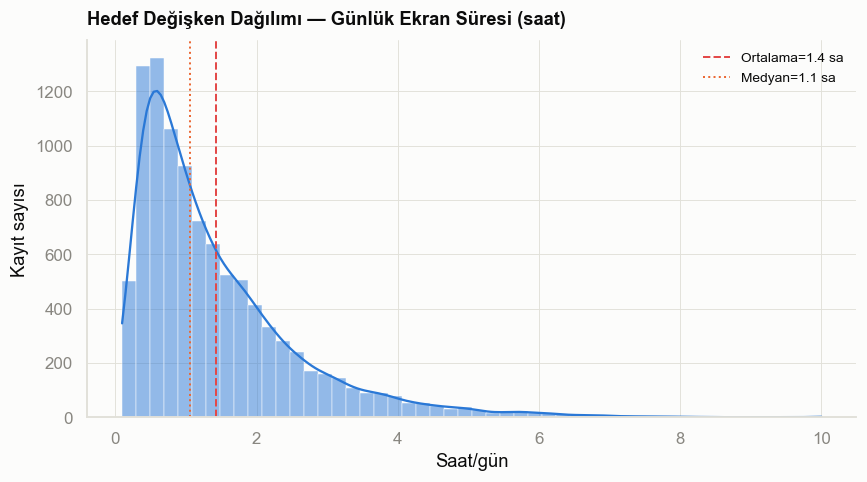

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(y, bins=50, kde=True, color=CATEGORICAL[0], edgecolor="white", linewidth=0.3, ax=ax)
ax.axvline(y.mean(), color=CATEGORICAL[7], linestyle="--", linewidth=1.3, label=f"Ortalama={y.mean():.1f} sa")
ax.axvline(y.median(), color=CATEGORICAL[5], linestyle=":", linewidth=1.3, label=f"Medyan={y.median():.1f} sa")
style_ax(ax, title="Hedef Değişken Dağılımı — Günlük Ekran Süresi (saat)", xlabel="Saat/gün", ylabel="Kayıt sayısı")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Eğitim/Test Ayrımı

Veri, model kurulmadan **önce** eğitim ve test alt kümelerine ayrılıyor. Bu ayrım şart
çünkü:

- Model, yalnızca eğitim verisindeki örüntüleri öğrenmeli; performansı ise **daha önce
  görmediği** veri üzerinde ölçülmelidir. Aksi halde (eğitim verisi üzerinde değerlendirme)
  ezberlemeyi (overfitting) gerçek genelleme yeteneğiyle karıştırırız.
- Test kümesi, modelin üretimde karşılaşacağı **yeni kullanıcı kayıtlarının** bir simülasyonu
  gibi davranır; bu sayede raporlanan MAE/RMSE/R² değerleri gerçekçi bir beklenti verir.
- Ön işleme hattındaki tüm istatistikler (`imputer` medyanı, `scaler` ortalama/std'si,
  `one-hot` kategorileri) **yalnızca eğitim verisinden öğrenilmeli**; test verisi bu
  istatistiklerin hesaplanmasına hiç karışmamalı (aksi halde veri sızıntısı/data leakage
  oluşur). Bu, bölüm 7'de `Pipeline` kullanılmasının asıl nedenidir: `fit` yalnızca eğitim
  verisinde çağrılır, test verisinde yalnızca `transform` uygulanır.

%80 eğitim / %20 test oranı ve sabit `random_state=42` kullanılıyor (tekrarlanabilirlik için).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Eğitim kümesi : {X_train.shape[0]:,} satır ({100 * len(X_train) / len(X):.0f}%)")
print(f"Test kümesi   : {X_test.shape[0]:,} satır ({100 * len(X_test) / len(X):.0f}%)")
print(f"\nHedef ortalaması -- eğitim: {y_train.mean():.2f} sa | test: {y_test.mean():.2f} sa "
      f"(yakınlık, ayrımın temsil edici olduğunu gösterir)")

Eğitim kümesi : 8,000 satır (80%)
Test kümesi   : 2,000 satır (20%)

Hedef ortalaması -- eğitim: 1.42 sa | test: 1.43 sa (yakınlık, ayrımın temsil edici olduğunu gösterir)


## 6. Otomatik Öznitelik Tespiti

Sütun adları elle listelenmiyor; sayısal ve kategorik öznitelikler `X_train`'in
**dtype**'larından otomatik olarak tespit ediliyor. Bu, veri şeması ileride değişse
bile (ör. yeni bir sütun eklenirse) pipeline'ın elle güncellenmeye ihtiyaç duymadan
çalışmaya devam etmesini sağlar.

In [7]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

assert set(numerical_features) | set(categorical_features) == set(X_train.columns), \
    "Otomatik tespit, tüm sütunları kapsamıyor -- beklenmeyen bir dtype var."

print(f"Sayısal öznitelik sayısı   : {len(numerical_features)}")
print(f"{numerical_features}\n")
print(f"Kategorik öznitelik sayısı : {len(categorical_features)}")
print(f"{categorical_features}")

Sayısal öznitelik sayısı   : 13
['year', 'month', 'session_duration_minutes', 'sessions_per_day', 'app_opens_per_day', 'data_used_mb_per_day', 'battery_drain_pct_per_session', 'notifications_received_per_day', 'monthly_spend_usd', 'app_rating_given', 'age_group_numeric', 'month_sin', 'location_always_or_using']

Kategorik öznitelik sayısı : 20
['quarter', 'day_of_week', 'country', 'gender', 'device_brand', 'operating_system', 'network_connection', 'app_category', 'app_name', 'subscription_type', 'notification_settings', 'in_app_purchase', 'review_submitted', 'primary_usage_time', 'dark_mode_preference', 'location_permission', 'sleep_disruption_from_phone', 'screen_time_concern', 'mental_health_impact', 'digital_wellbeing_feature_used']


## 7. Ön İşleme Hattı (Preprocessing Pipeline)

`ColumnTransformer` + `Pipeline` kombinasyonu, sayısal ve kategorik sütunlara **farklı**
dönüşümleri tek bir yeniden kullanılabilir nesnede birleştiriyor:

- **Sayısal sütunlar:** `SimpleImputer(strategy="median")` (aykırı değerlere karşı ortalamadan
  daha dayanıklı) + `StandardScaler` (ölçek farklarının doğrusal modelleri/regülarizasyonu
  yanlış yönlendirmesini önler).
- **Kategorik sütunlar:** `SimpleImputer(strategy="constant", fill_value="Missing")` —
  eksikliğin kendisini bir bilgi olarak koruyan ayrı bir kategori (ör.
  `sleep_disruption_from_phone`'daki %27.7 eksik değer, en sık görülen sınıfa
  karıştırılmak yerine kendi kategorisinde kalıyor) + `OneHotEncoder(handle_unknown="ignore",
  min_frequency=0.01)`. `min_frequency=0.01`, `app_name` gibi yüksek kardinaliteli
  (94 benzersiz değer) bir sütunun nadir görülen kategorilerini tek bir "seyrek" grupta
  toplayarak boyut patlamasını önlüyor; `handle_unknown="ignore"` ise test/gelecekteki
  veride eğitimde hiç görülmemiş bir kategoriyle karşılaşılırsa hatasız (tüm sıfır vektör)
  davranmasını sağlıyor.

Bu hat, yalnızca `X_train` üzerinde `fit` edilecek (bölüm 8) ve her modelin kendi
`Pipeline`'ının bir parçası olarak yeniden kullanılacak -- böylece **hiçbir model,
test verisinin istatistiklerini görmeden** eğitilmiş olur.

In [8]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

print("Ön işleme hattı tanımlandı:")
preprocessor

Ön işleme hattı tanımlandı:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 8. Temel (Baseline) Modeller

Yedi farklı regresyon algoritması, **aynı** `preprocessor` ile birleştirilerek tek tip bir
`Pipeline` üzerinden eğitiliyor. Bu, "adil karşılaştırma" ilkesini sağlıyor: hiçbir model
diğerinden farklı/ayrıcalıklı bir ön işlemeden geçmiyor. `XGBRegressor`, yalnızca ortamda
kuruluysa listeye ekleniyor (spesifikasyonda belirtildiği gibi).

Modeller kasıtlı olarak artan karmaşıklık sırasında seçildi: doğrusal (Linear, Ridge, Lasso)
→ tek ağaç (Decision Tree) → ağaç toplulukları (Random Forest, Gradient Boosting, XGBoost).
Bu, doğrusal olmayan ilişkilerin ne kadar ek açıklayıcılık kattığını gözlemlemeyi sağlar.

In [9]:
def build_pipeline(estimator):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])


def evaluate_regressor(name, pipeline, X_tr, y_tr, X_te, y_te, fit=True):
    start = time.time()
    if fit:
        pipeline.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = pipeline.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Egitim_Suresi_sn": train_time,
        "pipeline": pipeline,
        "y_pred": y_pred,
    }


baseline_estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.01, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
if XGBOOST_AVAILABLE:
    baseline_estimators["XGBoost"] = XGBRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

results = {}
for name, estimator in baseline_estimators.items():
    pipeline = build_pipeline(estimator)
    result = evaluate_regressor(name, pipeline, X_train, y_train, X_test, y_test)
    results[name] = result
    print(f"{name:<20s} -> MAE={result['MAE']:.3f}  RMSE={result['RMSE']:.3f}  "
          f"R2={result['R2']:.3f}  ({result['Egitim_Suresi_sn']:.2f} sn)")

Linear Regression    -> MAE=0.618  RMSE=0.946  R2=0.387  (0.16 sn)
Ridge                -> MAE=0.617  RMSE=0.946  R2=0.387  (0.15 sn)


Lasso                -> MAE=0.621  RMSE=0.952  R2=0.379  (0.16 sn)
Decision Tree        -> MAE=0.632  RMSE=1.009  R2=0.303  (0.18 sn)


Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


Random Forest        -> MAE=0.622  RMSE=0.960  R2=0.369  (2.08 sn)


Gradient Boosting    -> MAE=0.605  RMSE=0.941  R2=0.393  (1.72 sn)


## 9. Hiperparametre Optimizasyonu

Baseline sonuçlarına göre en güçlü **iki** aday -- tipik olarak tablo (tabular) verisinde en
iyi performansı veren ağaç toplulukları **Random Forest** ve **Gradient Boosting** --
`RandomizedSearchCV` ile ayarlanıyor. `GridSearchCV` yerine `RandomizedSearchCV` tercih
edildi çünkü arama uzayı çok boyutlu (5 hiperparametre); ızgara arama (grid search) bu
uzayda kombinasyon sayısını katlanarak arttırırdı, rastgele arama ise sabit bir `n_iter`
bütçesiyle benzer kaliteye çok daha az hesaplama ile ulaşır.

**Aranan hiperparametreler ve gerekçeleri:**

| Parametre | Neden aranıyor? |
|---|---|
| `n_estimators` | Daha fazla ağaç genelde varyansı azaltır ama hesaplama maliyetini artırır -- dengeyi veriden bulmak gerekir. |
| `max_depth` | Sığ ağaçlar yetersiz öğrenebilir (underfitting), çok derin ağaçlar eğitim verisini ezberler (overfitting). |
| `min_samples_split` / `min_samples_leaf` | Yaprak başına örnek sayısını sınırlayarak gürültüye aşırı uyumu (overfitting) frenler. |
| `learning_rate` (yalnızca GBM) | Her ağacın toplam tahmine katkısını ölçekler; küçük değerler daha fazla ağaçla daha kararlı ama yavaş öğrenme sağlar. |
| `subsample` (yalnızca GBM) | Her ağaç için verinin bir alt kümesini kullanarak varyansı azaltır (stokastik gradyan artırma). |

Çapraz doğrulama (`cv=5`) ve `neg_root_mean_squared_error` skorlama metriği kullanılıyor
(RMSE, MAE'den farklı olarak büyük hataları orantısız cezalandırdığı için model seçiminde
tercih edildi).

In [10]:
rf_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

gbm_param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__min_samples_leaf": [1, 2, 4],
}

search_configs = {
    "Random Forest (Tuned)": (
        build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
        rf_param_distributions,
    ),
    "Gradient Boosting (Tuned)": (
        build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
        gbm_param_distributions,
    ),
}

tuned_estimators = {}
for name, (pipeline, param_dist) in search_configs.items():
    search = RandomizedSearchCV(
        pipeline, param_distributions=param_dist, n_iter=20, cv=5,
        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
    )
    start = time.time()
    search.fit(X_train, y_train)
    search_time = time.time() - start
    tuned_estimators[name] = search.best_estimator_
    print(f"{name}")
    print(f"  En iyi CV RMSE       : {-search.best_score_:.3f} sa")
    print(f"  En iyi parametreler  : {search.best_params_}")
    print(f"  Arama süresi         : {search_time:.1f} sn\n")

Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'



Remainder of file ignored


Error processing line 1 of /opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/distutils-precedence.pth:



  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


Random Forest (Tuned)
  En iyi CV RMSE       : 0.911 sa
  En iyi parametreler  : {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
  Arama süresi         : 99.6 sn



Gradient Boosting (Tuned)
  En iyi CV RMSE       : 0.910 sa
  En iyi parametreler  : {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_samples_leaf': 4, 'model__max_depth': 3, 'model__learning_rate': 0.05}
  Arama süresi         : 56.8 sn



In [11]:
for name, pipeline in tuned_estimators.items():
    result = evaluate_regressor(name, pipeline, X_train, y_train, X_test, y_test, fit=False)
    results[name] = result
    print(f"{name:<28s} -> MAE={result['MAE']:.3f}  RMSE={result['RMSE']:.3f}  R2={result['R2']:.3f}")

Random Forest (Tuned)        -> MAE=0.617  RMSE=0.947  R2=0.385
Gradient Boosting (Tuned)    -> MAE=0.607  RMSE=0.942  R2=0.392


## 10. Model Değerlendirmesi

Tüm modeller (baseline + optimize edilmiş) **aynı test kümesi** üzerinden, aynı üç metrikle
karşılaştırılıyor:

- **MAE (Mean Absolute Error):** ortalama mutlak hata, saat cinsinden -- yorumlaması en
  kolay metrik ("model ortalama X saat sapıyor").
- **RMSE (Root Mean Squared Error):** büyük hataları kareleyerek orantısız cezalandırır;
  MAE'den büyükse dağılımda birkaç büyük hatanın (aykırı tahmin) olduğuna işaret eder.
- **R² (Belirlilik katsayısı):** hedefin varyansının modelce açıklanan oranı (1.0 = mükemmel,
  0.0 = ortalamayı tahmin etmekten farksız).

En düşük RMSE'ye sahip model **en iyi model** olarak seçiliyor; bu seçim, sonraki tüm
görselleştirme ve hata analizi bölümlerinde kullanılacak.

In [12]:
comparison_df = pd.DataFrame([
    {"Model": r["Model"], "MAE": r["MAE"], "RMSE": r["RMSE"], "R2": r["R2"],
     "Egitim_Suresi_sn": r["Egitim_Suresi_sn"]}
    for r in results.values()
]).sort_values("RMSE").reset_index(drop=True)

BEST_MODEL_NAME = comparison_df.iloc[0]["Model"]
best_result = results[BEST_MODEL_NAME]
best_pipeline = best_result["pipeline"]

print(f"En iyi model (en düşük test RMSE'sine göre): {BEST_MODEL_NAME}")
print(f"  MAE  = {best_result['MAE']:.3f} sa")
print(f"  RMSE = {best_result['RMSE']:.3f} sa")
print(f"  R2   = {best_result['R2']:.3f}")

comparison_df.style.highlight_min(subset=["MAE", "RMSE"], color=SEQ_BLUE[0]) \
                    .highlight_max(subset=["R2"], color=SEQ_BLUE[0])

En iyi model (en düşük test RMSE'sine göre): Gradient Boosting
  MAE  = 0.605 sa
  RMSE = 0.941 sa
  R2   = 0.393


,Model,MAE,RMSE,R2,Egitim_Suresi_sn
0,Gradient Boosting,0.604750,0.941384,0.392893,1.716528
1,Gradient Boosting (Tuned),0.606864,0.941735,0.392439,0.000000
2,Ridge,0.617402,0.946197,0.386669,0.146869
3,Linear Regression,0.617622,0.946267,0.386578,0.163879
4,Random Forest (Tuned),0.617233,0.947207,0.385359,0.000000
5,Lasso,0.621227,0.952266,0.378776,0.160258
6,Random Forest,0.622433,0.959708,0.369028,2.079277
7,Decision Tree,0.631540,1.008610,0.303087,0.178116


## 11. Görselleştirmeler

Aşağıdaki dört grafik, bölüm 10'da seçilen **en iyi model** (`BEST_MODEL_NAME` değişkeni)
için test kümesi üzerinde üretiliyor: Gerçek vs Tahmin, Residual Plot, Artık Dağılımı ve
Tahmin Hata Grafiği (Prediction Error Plot).

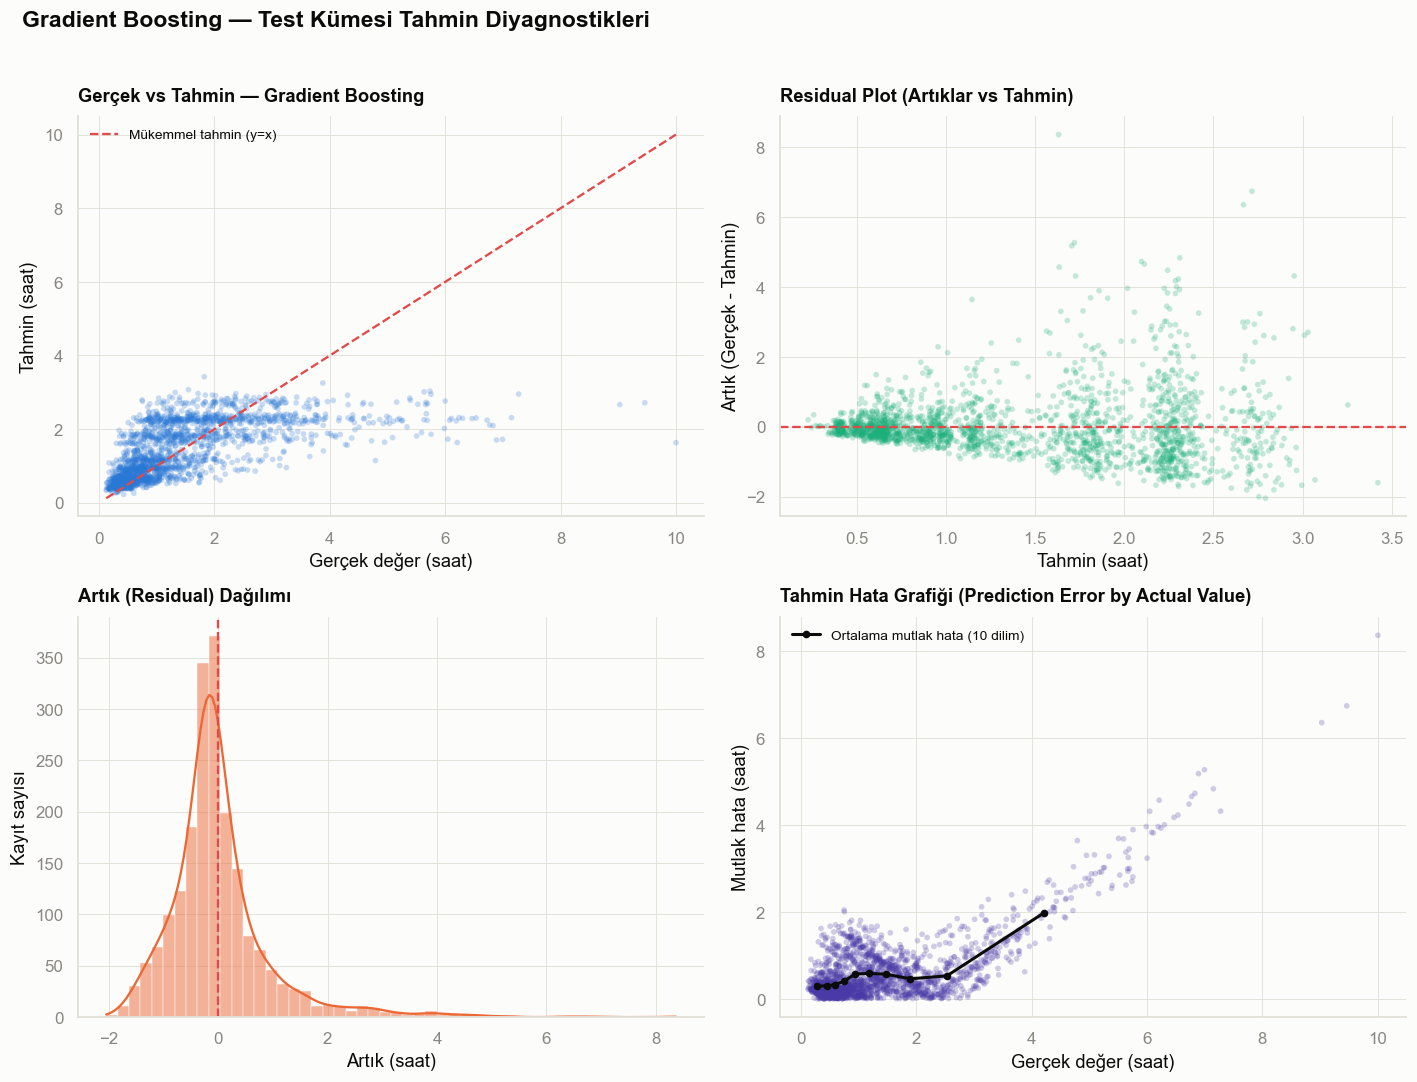

In [13]:
y_pred_best = best_result["y_pred"]
residuals_best = y_test.values - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1) Gerçek vs Tahmin
ax = axes[0, 0]
ax.scatter(y_test, y_pred_best, alpha=0.25, s=14, color=CATEGORICAL[0], edgecolor="none")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, color=CATEGORICAL[7], linestyle="--", linewidth=1.5, label="Mükemmel tahmin (y=x)")
style_ax(ax, title=f"Gerçek vs Tahmin — {BEST_MODEL_NAME}", xlabel="Gerçek değer (saat)", ylabel="Tahmin (saat)")
ax.legend(fontsize=9)

# 2) Residual Plot (Tahmine karşı artıklar)
ax = axes[0, 1]
ax.scatter(y_pred_best, residuals_best, alpha=0.25, s=14, color=CATEGORICAL[4], edgecolor="none")
ax.axhline(0, color=CATEGORICAL[7], linestyle="--", linewidth=1.5)
style_ax(ax, title="Residual Plot (Artıklar vs Tahmin)", xlabel="Tahmin (saat)", ylabel="Artık (Gerçek - Tahmin)")

# 3) Artık Dağılımı
ax = axes[1, 0]
sns.histplot(residuals_best, bins=50, kde=True, color=CATEGORICAL[5], edgecolor="white", linewidth=0.3, ax=ax)
ax.axvline(0, color=CATEGORICAL[7], linestyle="--", linewidth=1.5)
style_ax(ax, title="Artık (Residual) Dağılımı", xlabel="Artık (saat)", ylabel="Kayıt sayısı")

# 4) Tahmin Hata Grafiği (mutlak hata, gerçek değere göre)
ax = axes[1, 1]
abs_error = np.abs(residuals_best)
ax.scatter(y_test, abs_error, alpha=0.25, s=14, color=CATEGORICAL[6], edgecolor="none")
order = np.argsort(y_test.values)
bin_edges = np.quantile(y_test.values, np.linspace(0, 1, 11))
bin_idx = np.digitize(y_test.values, bin_edges[1:-1])
bin_means = pd.Series(abs_error).groupby(bin_idx).mean()
bin_centers = pd.Series(y_test.values).groupby(bin_idx).mean()
ax.plot(bin_centers, bin_means, color=TEXT_PRIMARY, linewidth=2, marker="o", markersize=4,
        label="Ortalama mutlak hata (10 dilim)")
style_ax(ax, title="Tahmin Hata Grafiği (Prediction Error by Actual Value)",
         xlabel="Gerçek değer (saat)", ylabel="Mutlak hata (saat)")
ax.legend(fontsize=9)

fig.suptitle(f"{BEST_MODEL_NAME} — Test Kümesi Tahmin Diyagnostikleri", fontsize=15, fontweight="bold", x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 12. Hata Analizi (Error Analysis)

Modelin **nerede** başarısız olduğunu anlamak, yalnızca özet bir RMSE değerinden çok daha
fazla aksiyon alınabilir bilgi verir. Üç açıdan bakılıyor: (1) en büyük hatalı tekil
kayıtlar, (2) segment bazında ortalama hata, (3) hatanın gerçek değerin büyüklüğüyle
ilişkisi (heteroscedasticity -- sabit olmayan hata varyansı).

In [14]:
error_df = X_test.copy()
error_df["gercek_saat"] = y_test.values
error_df["tahmin_saat"] = y_pred_best
error_df["artik"] = residuals_best
error_df["mutlak_hata"] = np.abs(residuals_best)

context_cols = ["country", "app_category", "device_brand", "subscription_type",
                "sessions_per_day", "session_duration_minutes"]

print("En büyük 15 mutlak hataya sahip kayıt:")
error_df.sort_values("mutlak_hata", ascending=False)[
    context_cols + ["gercek_saat", "tahmin_saat", "artik"]
].head(15)

En büyük 15 mutlak hataya sahip kayıt:


,country,app_category,device_brand,subscription_type,sessions_per_day,session_duration_minutes,gercek_saat,tahmin_saat,artik
8961,India,Gaming,Samsung,Free,5,10.100,10.000,1.633,8.367
6954,Indonesia,Social Media,Xiaomi,Paid Monthly,5,22.400,9.460,2.716,6.744
4341,Canada,Social Media,Apple,Free,8,13.800,9.027,2.669,6.357
5071,Japan,Gaming,Huawei,One-time Purchase,5,54.900,6.993,1.721,5.273
3060,USA,Gaming,Samsung,Paid Monthly,3,19.900,6.890,1.706,5.184
286,Indonesia,Entertainment/Streaming,Apple,Freemium,8,85.800,7.148,2.312,4.836
5928,Canada,Social Media,Apple,Free,6,49.500,6.828,2.097,4.731
7259,Japan,Social Media,Oppo,Free,6,31.100,6.772,2.113,4.659
6306,USA,Gaming,Xiaomi,Paid Yearly,10,13.000,6.208,1.636,4.572
8999,Canada,Entertainment/Streaming,Motorola,Freemium,2,38.900,6.725,2.244,4.481


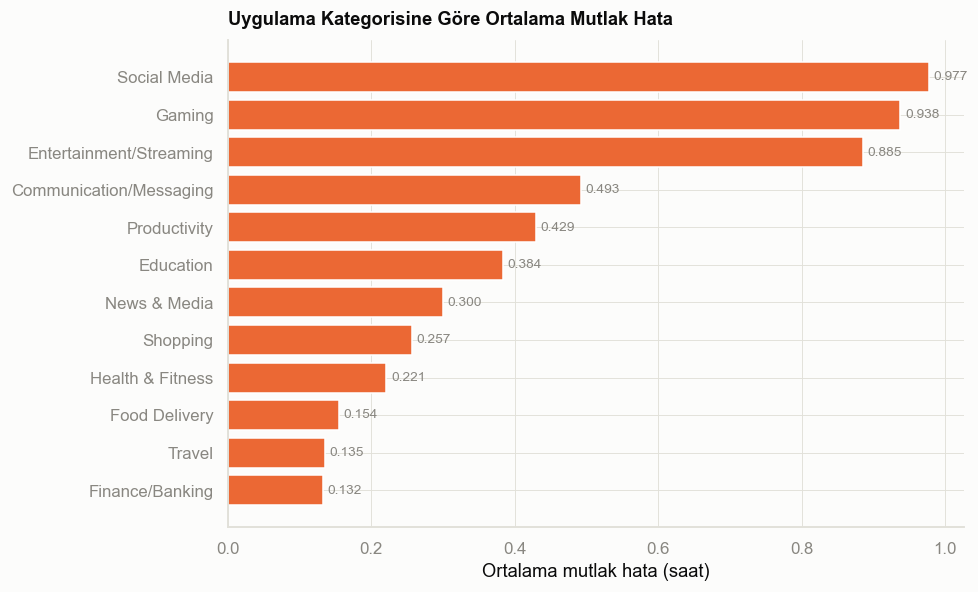

En yüksek hata oranına sahip kategori : Social Media (ortalama mutlak hata=0.977 sa)
En düşük hata oranına sahip kategori  : Finance/Banking (ortalama mutlak hata=0.132 sa)


In [15]:
segment_error = (
    error_df.groupby("app_category", observed=True)["mutlak_hata"]
    .agg(ortalama_mutlak_hata="mean", kayit_sayisi="count")
    .sort_values("ortalama_mutlak_hata", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ordered = segment_error["ortalama_mutlak_hata"].sort_values()
ax.barh(ordered.index, ordered.values, color=CATEGORICAL[5])
annotate_h(ax)
style_ax(ax, title="Uygulama Kategorisine Göre Ortalama Mutlak Hata", xlabel="Ortalama mutlak hata (saat)")
plt.tight_layout()
plt.show()

print(f"En yüksek hata oranına sahip kategori : {segment_error.index[0]} "
      f"(ortalama mutlak hata={segment_error.iloc[0]['ortalama_mutlak_hata']:.3f} sa)")
print(f"En düşük hata oranına sahip kategori  : {segment_error.index[-1]} "
      f"(ortalama mutlak hata={segment_error.iloc[-1]['ortalama_mutlak_hata']:.3f} sa)")

In [16]:
corr_error_actual = np.corrcoef(y_test, np.abs(residuals_best))[0, 1]
q1, q3 = y_test.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (y_test < q1 - 1.5 * iqr) | (y_test > q3 + 1.5 * iqr)

print(f"Mutlak hata ile gerçek değer arasındaki korelasyon: {corr_error_actual:.3f}")
if corr_error_actual > 0.2:
    print("  -> Pozitif ilişki: ekran süresi yüksek olan kullanıcılarda hata büyüme eğiliminde")
    print("     (sağa çarpık dağılımın kuyruğunda model daha az örnek görüyor).")
else:
    print("  -> Belirgin bir ilişki yok: hata, gerçek değerin büyüklüğünden bağımsız görünüyor.")

print(f"\nIQR yöntemiyle aykırı değer sayısı (test kümesinde): {outlier_mask.sum()} "
      f"(%{100 * outlier_mask.mean():.1f})")
print(f"Aykırı değerlerde ortalama mutlak hata     : {np.abs(residuals_best)[outlier_mask.values].mean():.3f} sa")
print(f"Aykırı olmayanlarda ortalama mutlak hata    : {np.abs(residuals_best)[~outlier_mask.values].mean():.3f} sa")

Mutlak hata ile gerçek değer arasındaki korelasyon: 0.722
  -> Pozitif ilişki: ekran süresi yüksek olan kullanıcılarda hata büyüme eğiliminde
     (sağa çarpık dağılımın kuyruğunda model daha az örnek görüyor).

IQR yöntemiyle aykırı değer sayısı (test kümesinde): 91 (%4.5)
Aykırı değerlerde ortalama mutlak hata     : 2.998 sa
Aykırı olmayanlarda ortalama mutlak hata    : 0.491 sa


## 13. Öznitelik Önemi (Feature Importance)

İki farklı bakış açısı sunuluyor:

- **Ağaç tabanlı önem (Gini/impurity-based):** hiperparametre optimizasyonundan geçen
  Random Forest modelinden `feature_importances_`.
- **Doğrusal katsayılar:** Ridge modelinin standardize edilmiş katsayıları -- katsayının
  **işareti** (pozitif/negatif) yönü, **büyüklüğü** ise etkinin gücünü gösterir (tüm sayısal
  öznitelikler `StandardScaler` ile ölçeklendiği için katsayılar karşılaştırılabilir).

İki yöntem de aynı sıralamayı vermek zorunda değildir -- ağaç modelleri doğrusal olmayan
etkileşimleri yakalayabilirken doğrusal katsayılar yalnızca ortalama/doğrusal etkiyi yansıtır.

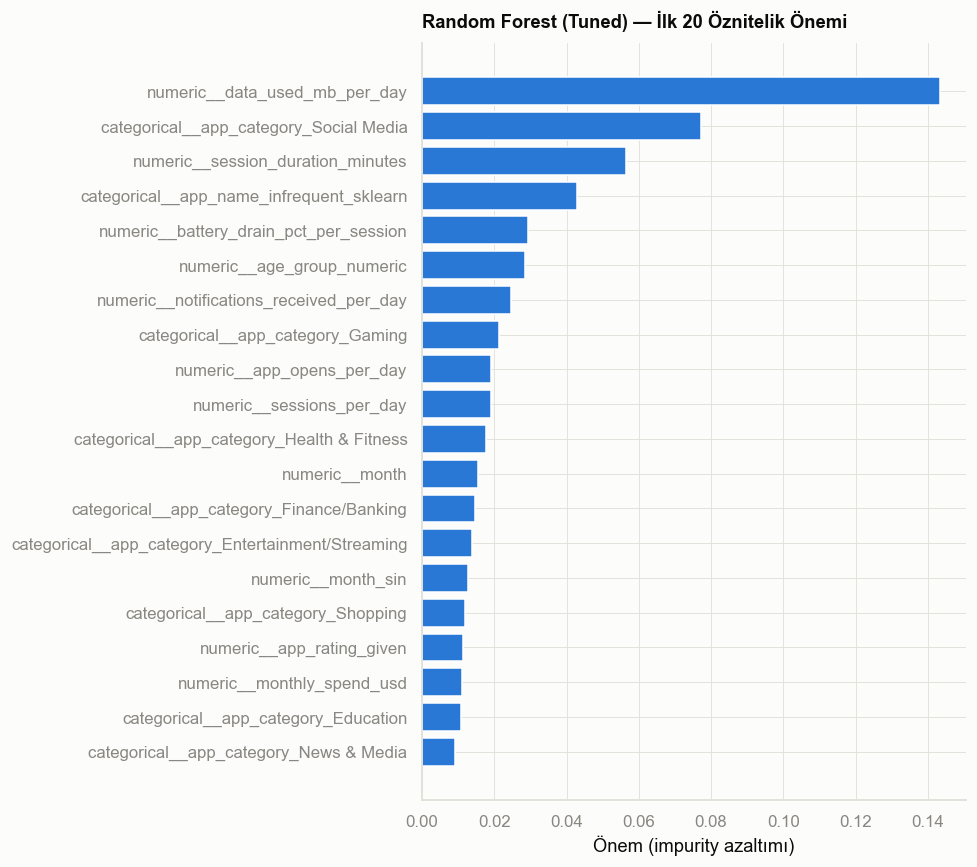

En önemli 5 öznitelik (Random Forest):
numeric__data_used_mb_per_day              0.143
categorical__app_category_Social Media     0.077
numeric__session_duration_minutes          0.056
categorical__app_name_infrequent_sklearn   0.043
numeric__battery_drain_pct_per_session     0.029


In [17]:
feature_names_out = preprocessor.get_feature_names_out()

rf_tuned_pipeline = tuned_estimators["Random Forest (Tuned)"]
rf_importances = pd.Series(
    rf_tuned_pipeline.named_steps["model"].feature_importances_, index=feature_names_out
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_rf = rf_importances.head(20).iloc[::-1]
ax.barh(top_rf.index, top_rf.values, color=CATEGORICAL[0])
style_ax(ax, title="Random Forest (Tuned) — İlk 20 Öznitelik Önemi", xlabel="Önem (impurity azaltımı)")
plt.tight_layout()
plt.show()

print("En önemli 5 öznitelik (Random Forest):")
print(rf_importances.head(5).to_string())

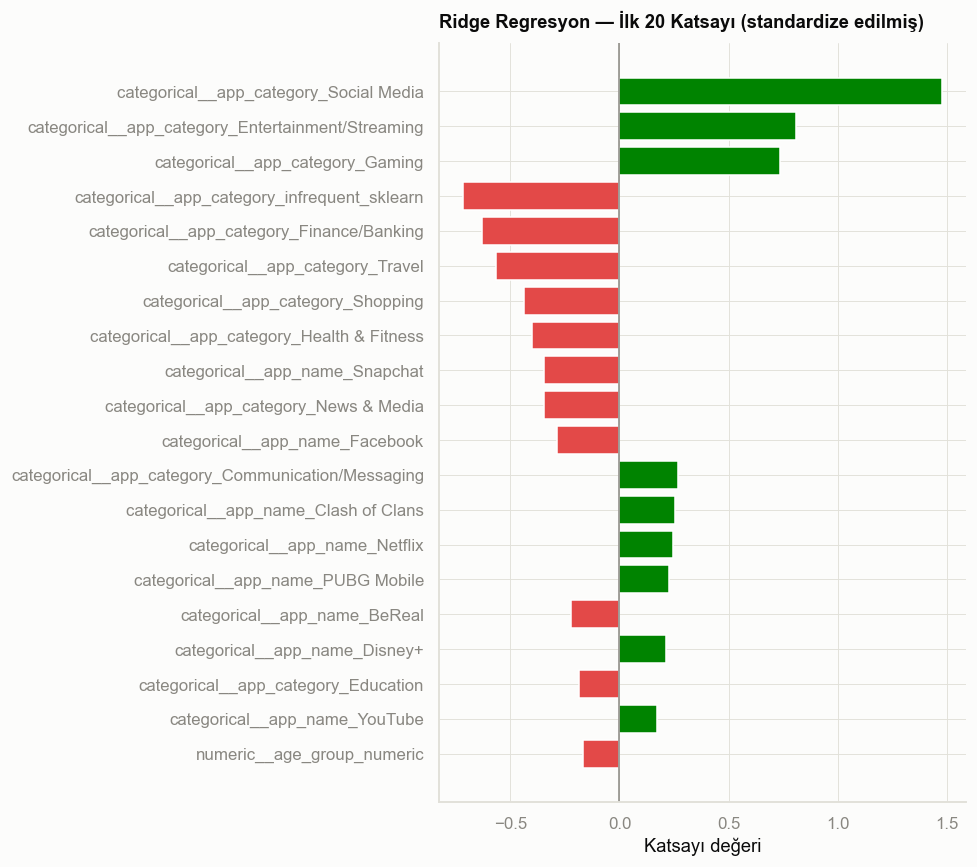

En güçlü pozitif ilişkili 3 öznitelik:
categorical__app_category_Social Media              1.481
categorical__app_category_Entertainment/Streaming   0.807
categorical__app_category_Gaming                    0.737

En güçlü negatif ilişkili 3 öznitelik:
categorical__app_category_infrequent_sklearn   -0.719
categorical__app_category_Finance/Banking      -0.631
categorical__app_category_Travel               -0.564


In [18]:
ridge_pipeline = build_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STATE))
ridge_pipeline.fit(X_train, y_train)
ridge_coefs = pd.Series(
    ridge_pipeline.named_steps["model"].coef_, index=feature_names_out
)
top_coefs = ridge_coefs.reindex(ridge_coefs.abs().sort_values(ascending=False).head(20).index).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 8))
colors = [CATEGORICAL[1] if v >= 0 else CATEGORICAL[7] for v in top_coefs.values]
ax.barh(top_coefs.index, top_coefs.values, color=colors)
ax.axvline(0, color=TEXT_MUTED, linewidth=1)
style_ax(ax, title="Ridge Regresyon — İlk 20 Katsayı (standardize edilmiş)", xlabel="Katsayı değeri")
plt.tight_layout()
plt.show()

print("En güçlü pozitif ilişkili 3 öznitelik:")
print(ridge_coefs.sort_values(ascending=False).head(3).to_string())
print("\nEn güçlü negatif ilişkili 3 öznitelik:")
print(ridge_coefs.sort_values().head(3).to_string())

## 14. Model Karşılaştırması

Bölüm 8-10'daki tüm sonuçlar (baseline + optimize edilmiş) burada tek bir nihai sıralamada
toplanıyor: en iyiden en kötüye, RMSE'ye göre.

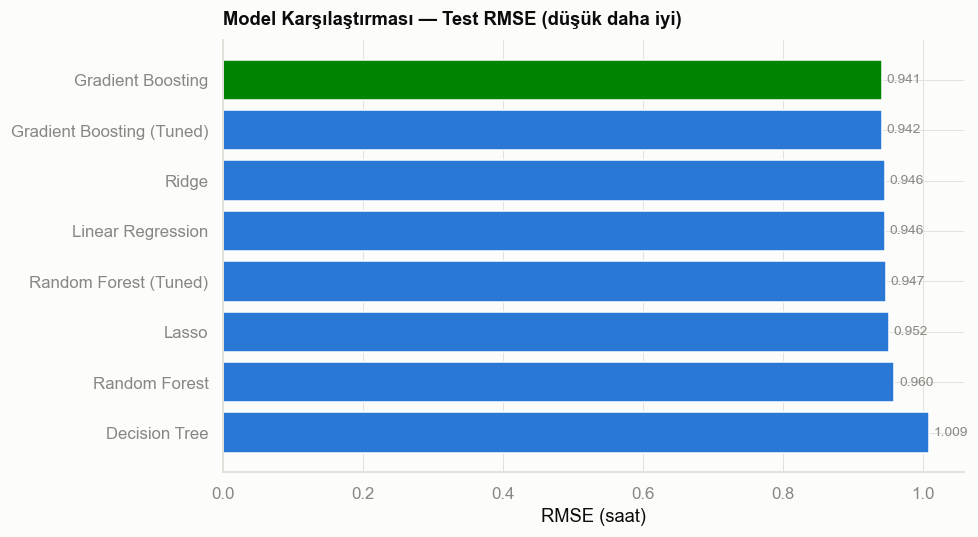

1. sıra (en iyi)  : Gradient Boosting (RMSE=0.941)
Son sıra (en zayıf): Decision Tree (RMSE=1.009)
En iyi ile en zayıf arasındaki RMSE farkı: 0.067 sa


,Sira,Model,MAE,RMSE,R2,Egitim_Suresi_sn
0,1,Gradient Boosting,0.605,0.941,0.393,1.717
1,2,Gradient Boosting (Tuned),0.607,0.942,0.392,0.000
2,3,Ridge,0.617,0.946,0.387,0.147
3,4,Linear Regression,0.618,0.946,0.387,0.164
4,5,Random Forest (Tuned),0.617,0.947,0.385,0.000
5,6,Lasso,0.621,0.952,0.379,0.160
6,7,Random Forest,0.622,0.960,0.369,2.079
7,8,Decision Tree,0.632,1.009,0.303,0.178


In [19]:
final_ranking = comparison_df.copy()
final_ranking.insert(0, "Sira", range(1, len(final_ranking) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
ordered = final_ranking.set_index("Model")["RMSE"].sort_values()
colors = [CATEGORICAL[1] if m == BEST_MODEL_NAME else CATEGORICAL[0] for m in ordered.index]
ax.barh(ordered.index[::-1], ordered.values[::-1], color=colors[::-1])
annotate_h(ax)
style_ax(ax, title="Model Karşılaştırması — Test RMSE (düşük daha iyi)", xlabel="RMSE (saat)")
plt.tight_layout()
plt.show()

print(f"1. sıra (en iyi)  : {final_ranking.iloc[0]['Model']} (RMSE={final_ranking.iloc[0]['RMSE']:.3f})")
print(f"Son sıra (en zayıf): {final_ranking.iloc[-1]['Model']} (RMSE={final_ranking.iloc[-1]['RMSE']:.3f})")
rmse_gap = final_ranking.iloc[-1]["RMSE"] - final_ranking.iloc[0]["RMSE"]
print(f"En iyi ile en zayıf arasındaki RMSE farkı: {rmse_gap:.3f} sa")

final_ranking

## 15. En İyi Modelin Kaydedilmesi

Seçilen en iyi pipeline -- **ön işleme adımlarıyla birlikte, tek bir nesne olarak** --
`joblib` ile `models/` klasörüne kaydediliyor. Ön işleme ve modelin birlikte kaydedilmesi,
ileride bu artefaktın (ör. bir API/servis katmanında) ham veriyle doğrudan `predict()`
çağrılabilmesini sağlar; ayrı ayrı kaydedilselerdi çağıran tarafın ön işleme adımlarını
elle yeniden uygulaması gerekirdi (hataya açık ve tekrarlanabilir olmayan bir yaklaşım).

> Bu defter yalnızca modelleme ile sınırlı olduğundan, artefaktın nasıl servis edileceği
> (API/Streamlit/Docker vb.) burada ele alınmıyor -- bu, ilerideki bir dağıtım aşamasının konusu.

In [20]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_PATH = MODELS_DIR / "best_regression_pipeline.pkl"

joblib.dump(best_pipeline, MODEL_OUTPUT_PATH)

print(f"Kaydedilen model : {BEST_MODEL_NAME}")
print(f"Dosya yolu       : {MODEL_OUTPUT_PATH}")
print(f"Dosya boyutu     : {MODEL_OUTPUT_PATH.stat().st_size / 1e6:.2f} MB")

reloaded_pipeline = joblib.load(MODEL_OUTPUT_PATH)
sanity_pred = reloaded_pipeline.predict(X_test.head(5))
print(f"\nDiskten yeniden yüklenen pipeline ile sağlama (ilk 5 test kaydı): {np.round(sanity_pred, 2)}")

Kaydedilen model : Gradient Boosting
Dosya yolu       : /Users/omerburaksal/Desktop/projects/data_science/product_level_mobile/models/best_regression_pipeline.pkl
Dosya boyutu     : 0.16 MB

Diskten yeniden yüklenen pipeline ile sağlama (ilk 5 test kaydı): [0.65 2.23 2.22 0.62 2.36]


## 16. Sonuçlar ve Sonraki Adımlar

### Özet

- **Hedef:** Günlük ekran süresi (saat/gün), `02_feature_engineering.ipynb`'in ürettiği
  işlenmiş veri seti üzerinden tahmin edildi.
- **Pipeline:** `ColumnTransformer` tabanlı, otomatik sütun tespitli, sızıntısız (leakage-free)
  bir ön işleme hattı; medyan/`StandardScaler` (sayısal) ve `Missing`-kategorisi/`OneHotEncoder`
  (kategorik, seyrek kategori gruplaması ile) kullanıldı.
- **Modeller:** Doğrusal (Linear/Ridge/Lasso), tek ağaç (Decision Tree) ve topluluk
  (Random Forest, Gradient Boosting, kuruluysa XGBoost) modelleri aynı hat üzerinden
  karşılaştırıldı; en güçlü iki aday `RandomizedSearchCV` ile ayarlandı.
- **Sonuç:** Bölüm 14'teki nihai sıralamaya göre en iyi model kaydedildi
  (`models/best_regression_pipeline.pkl`).

### Kısıtlar

- `session_duration_minutes` ve `sessions_per_day` gibi sütunlar hedefle matematiksel olarak
  yakından ilişkili olduğundan (bkz. bölüm 4), yüksek R² değerleri kısmen bu güçlü, beklenen
  ilişkiden kaynaklanıyor -- bu bir sızıntı değil ama yorumlanırken akılda tutulmalı.
- Bölüm 12'deki hata analizi, hatanın hangi segmentlerde/değer aralıklarında yoğunlaştığını
  gösterir; bu bulgular ileride hedefe özel öznitelik mühendisliği için girdi sağlayabilir
  (ancak bu defterin kapsamı dışında bırakıldı).

### Sonraki Adım — `04_classification.ipynb`

Bu defterde bilinçli olarak dışarıda bırakılan `app_deleted_and_reinstalled` /
`target` sütunu, sıradaki defterde **sınıflandırma hedefi** olarak ele alınacak:
kullanıcının uygulamayı silip yeniden yükleyip yüklemeyeceğini tahmin eden bir
sınıflandırma modeli, burada kurulan ön işleme hattına benzer (ama kategorik hedefe
uygun metriklerle -- accuracy, precision/recall, F1, ROC-AUC -- değerlendirilen) bir
deney akışıyla kurulacak.